<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/from_scratch_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1단계: 데이터셋 파악하기

In [1]:
# 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive') # 많이 하는 실수: content 앞에도 / 붙이기

Mounted at /content/drive


In [2]:
# pandas 라이브러리 불러오기

import pandas as pd

In [3]:
# train 폴더의 '01_M01_DC_train.csv 파일 분석해보기

dir_train_01 = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv'

df_train_01 = pd.read_csv(dir_train_01)

print("행, 렬:", df_train_01.shape)
print("열 항목:", df_train_01.columns.tolist())

행, 렬: (3124704, 24)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


In [4]:
# train_ttf 폴더의 '01_M01_DC_train.csv' 파일 분석해보기

dir_ttf_01 = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'

df_ttf_01 = pd.read_csv(dir_ttf_01)

print("행, 렬:", df_ttf_01.shape)
print("열 항목:", df_ttf_01.columns.tolist())

행, 렬: (3124704, 4)
열 항목: ['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [5]:
# train_ttf 폴더 속 파일의 열 항목 이름이 너무 긺으로 축약

df_ttf_01 = df_ttf_01.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
})

# 항목 이름이 잘 변경 되었나 확인해보기
print("변경된 열 항목:", df_ttf_01.columns.tolist())

변경된 열 항목: ['time', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [6]:
# train_failure 폴더 속 '01_M01_train_fault_data.csv' 분석해보기

dir_failure_01 = '/content/drive/MyDrive/phm18/train_faults/01_M01_train_fault_data.csv'

df_failure_01 = pd.read_csv(dir_failure_01)

print("행, 렬:", df_failure_01.shape)
print("열 항목:", df_failure_01.columns.tolist())

# 열 항목의 이름으로 보아, 해당 데이터는 고장이 발생했을 때를 기록한 파일로 추측된다.

행, 렬: (19, 3)
열 항목: ['time', 'fault_name', 'Tool']


In [7]:
# 시각화를 위해 df_train_01과 df_ttf_01을 'time'에 대해 merge

df_merged_01 = df_train_01.merge(df_ttf_01, on='time')

# merge가 잘 되었는지 확인해보기

print("행, 렬", df_merged_01.shape)
print("열 항목:", df_merged_01.columns.tolist())

행, 렬 (3135742, 27)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


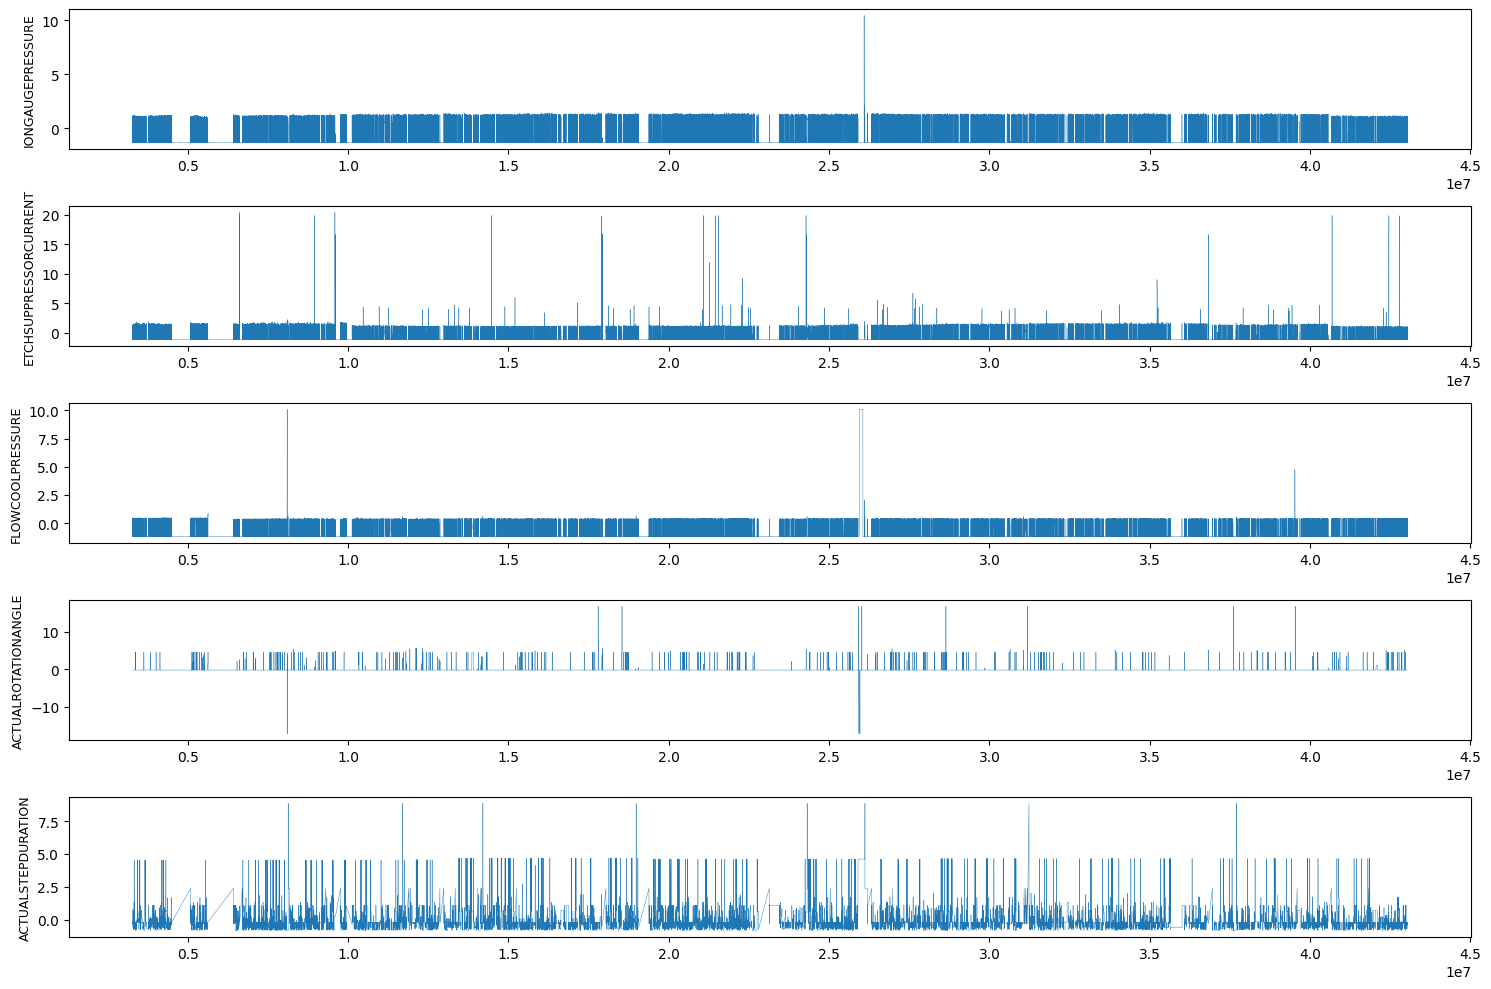

In [8]:
from matplotlib.axes import Axes
# 우선 센서값들에 대해 시각화 해보기
sensor_cols = ['IONGAUGEPRESSURE',
               'ETCHSUPPRESSORCURRENT',
               'FLOWCOOLPRESSURE',
               'ACTUALROTATIONANGLE',
               'ACTUALSTEPDURATION']

import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2)) # 도화지부터 준비하기
# plt.figure, plt.subplots

for i, col in enumerate(sensor_cols):
  axes[i].plot( df_merged_01['time'], df_merged_01[col], linewidth=0.3 )
  axes[i].set_ylabel(col, fontsize=9)

plt.tight_layout()
plt.show()

IONGAUGEPRESSURE 변수가 2.5e7 ~ 2.7e7 부근에서 확 튀는 것(spike)을 확인할 수 있다. 해당 시간대를 유심히 살펴보자.

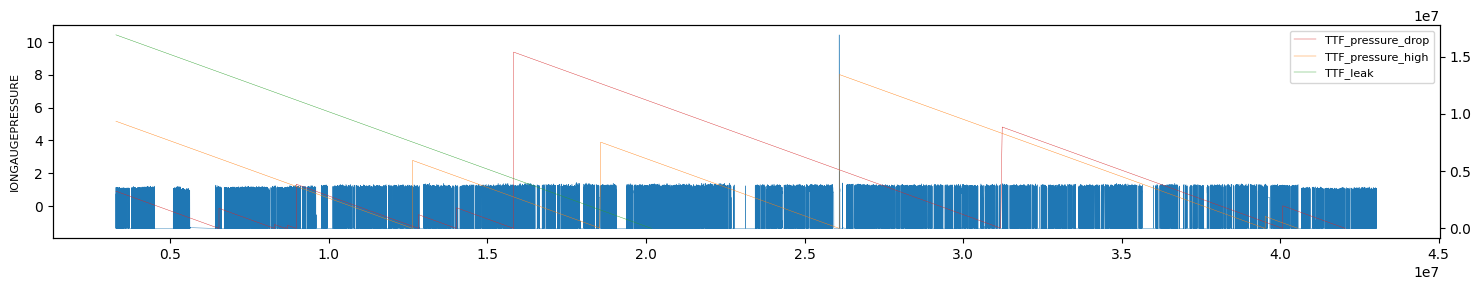

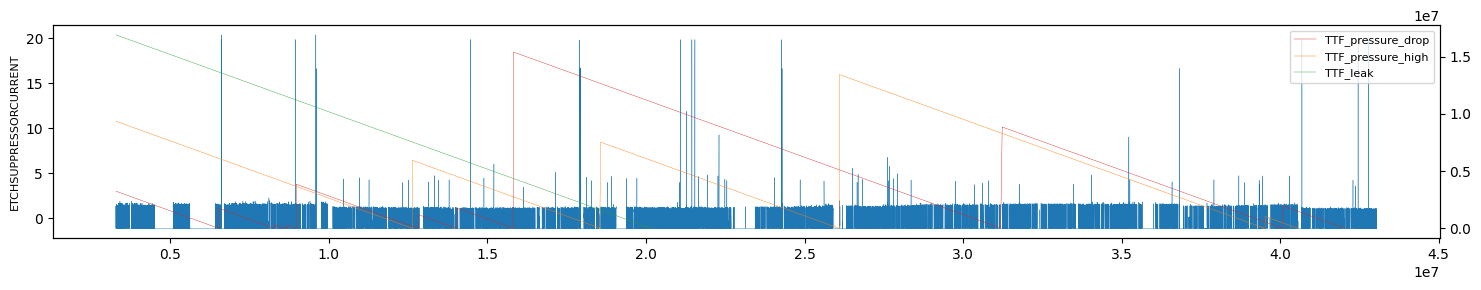

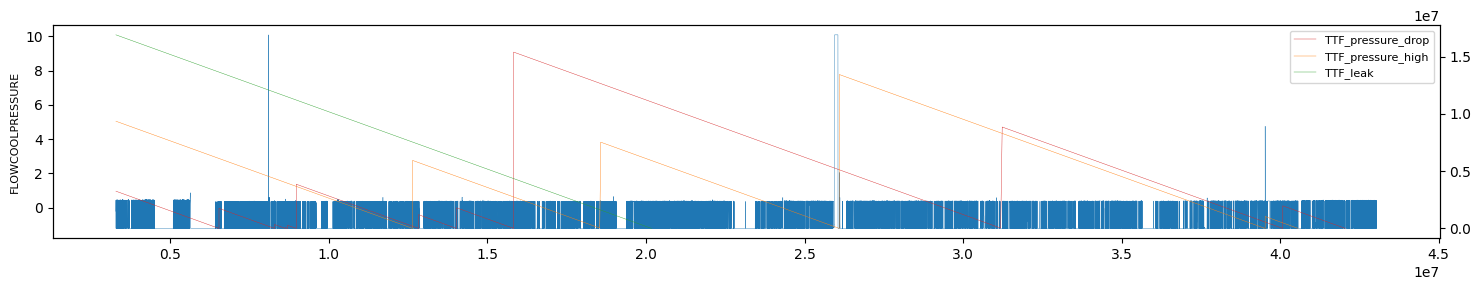

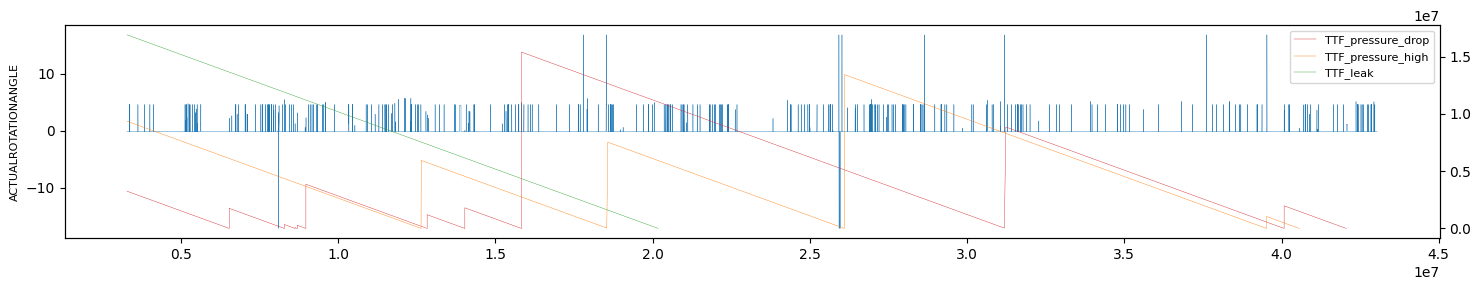

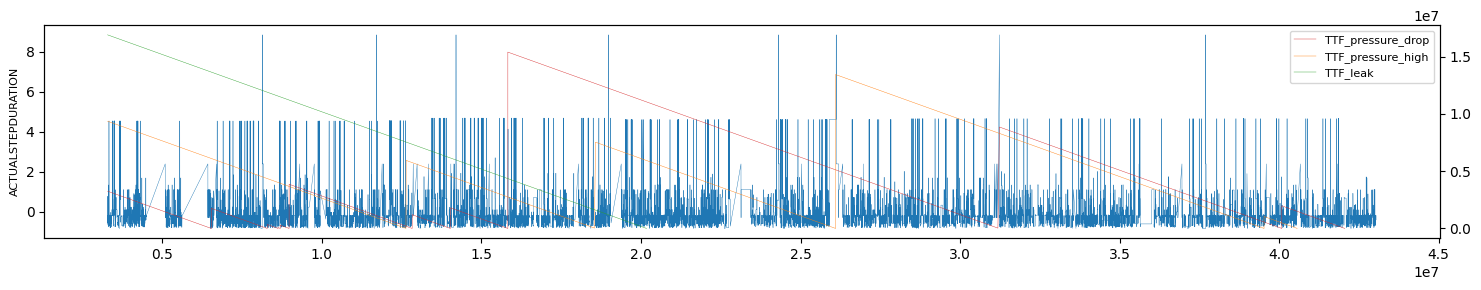

In [16]:
###
# ttf 파일의 변수도 함께 그려보자.

ttf_cols = ['TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


for col in sensor_cols:
  # FIXME: figzise라고 씀
  fig, ax1 = plt.subplots(figsize=(15, 3)) # FIXME: 도화지를 다섯 장 준비해야 하므로 for문 안에 넣기
  ax1.plot( df_merged_01['time'], df_merged_01[col], linewidth=0.3,
           color='tab:blue', label=col )
  ax1.set_ylabel(col, fontsize=8)

  ax2 = ax1.twinx()
  ax2.plot( df_merged_01['time'], df_merged_01['TTF_pressure_drop'], linewidth=0.3,
           color='tab:red', label='TTF_pressure_drop')
  ax2.plot( df_merged_01['time'], df_merged_01['TTF_pressure_high'], linewidth=0.3,
           color='tab:orange', label='TTF_pressure_high')
  ax2.plot( df_merged_01['time'], df_merged_01['TTF_leak'], linewidth=0.3,
           color='tab:green', label='TTF_leak')

  ax2.legend(fontsize=8, loc='upper right')

  plt.tight_layout() # 여기서는 for문 안에 넣어야 크기가 들쭉날쭉 안 하더라
  plt.show()

ttf 변수도 함께 그려보면 2.5e7 ~ 2.7e7 구간에서 'TTF_pressure_high' 고장이 발생했음을 알 수 있다.

In [20]:
# 시각화만으로는 분석에 한계가 있으므로, 변수 간 상관관계도 알아보자

corr_01 = df_merged_01[sensor_cols + ttf_cols].corr()
corr_01_sensor_ttf = corr_01.loc[sensor_cols, ttf_cols]

print(corr_01_sensor_ttf)

                       TTF_pressure_drop  TTF_pressure_high  TTF_leak
IONGAUGEPRESSURE                0.010567           0.008017 -0.001035
ETCHSUPPRESSORCURRENT          -0.015696           0.026035  0.090449
FLOWCOOLPRESSURE                0.000423          -0.103868  0.035274
ACTUALROTATIONANGLE            -0.037254           0.001671 -0.031271
ACTUALSTEPDURATION              0.000578          -0.034361  0.005758


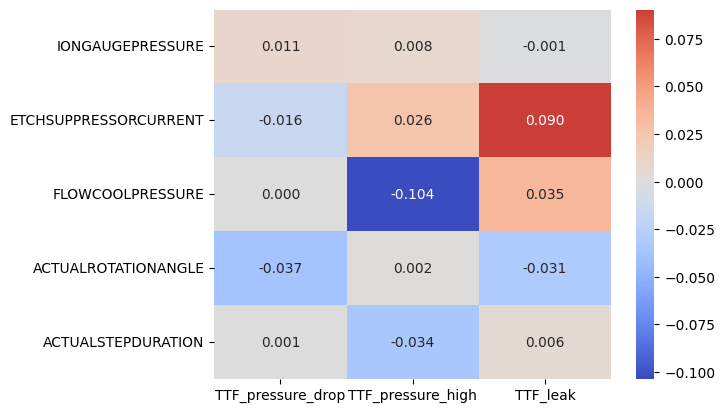

<Figure size 1500x300 with 0 Axes>

In [22]:
# 이대로는 알아보기가 힘드니 heatmap을 그리자

import seaborn as sns

sns.heatmap(corr_01_sensor_ttf,
            fmt = '.3f',
            annot = True,
            cmap = 'coolwarm',
            center = 0)

plt.figure(figsize=(15, 3))
plt.tight_layout()
plt.show()

센서값과 ttf 변수 사이에는 상관관계가 약한 편이다. 전체 데이터 중 센서값의 스파이크가 나타나는 구간이 극히 짧아서, 평균적인 상관관계 계산에서는 잘 드러나지 않는 것으로 보인다.